Dataset Shape: (100000, 12)

Data Types:
 shoe_id                 int64
cards_remaining         int64
dealer_up               int64
initial_hand           object
dealer_final           object
dealer_final_value     object
player_final           object
player_final_value     object
actions_taken          object
run_count               int64
true_count              int64
win                   float64
dtype: object

Missing Values:
 shoe_id               0
cards_remaining       0
dealer_up             0
initial_hand          0
dealer_final          0
dealer_final_value    0
player_final          0
player_final_value    0
actions_taken         0
run_count             0
true_count            0
win                   0
dtype: int64

Descriptive Statistics:
              shoe_id  cards_remaining      dealer_up      run_count  \
count  100000.000000    100000.000000  100000.000000  100000.000000   
mean   411189.170090       248.742740       7.308810       0.091870   
std    237225.549333      

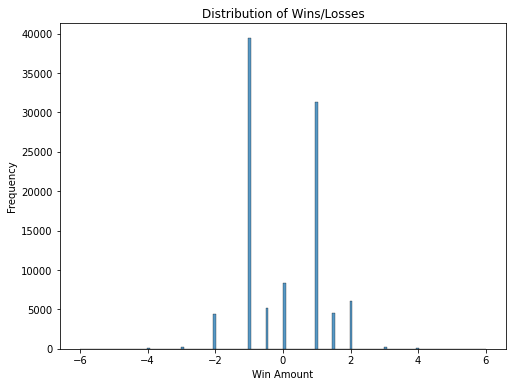

Win Percentage: 42.31%

Average Win by Dealer Upcard:
 dealer_up
6     0.251913
5     0.185568
4     0.173404
7     0.135470
3     0.122526
2     0.095937
8     0.073127
9    -0.025072
10   -0.164829
11   -0.371808
Name: win, dtype: float64


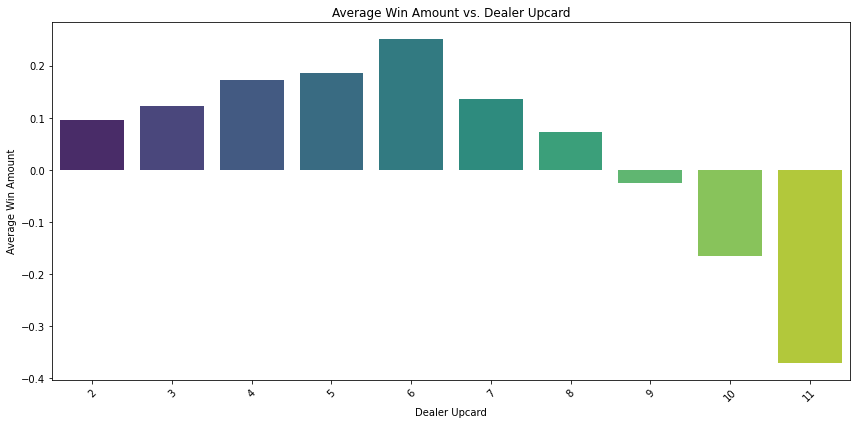


Average Win by Initial Hand:
 initial_hand
[11, 10]    1.439702
[10, 11]    1.430876
[9, 11]     0.563847
[11, 9]     0.563694
[10, 10]    0.561342
              ...   
[6, 10]    -0.394571
[5, 10]    -0.405198
[7, 8]     -0.431897
[9, 4]     -0.435216
[7, 9]     -0.442761
Name: win, Length: 100, dtype: float64


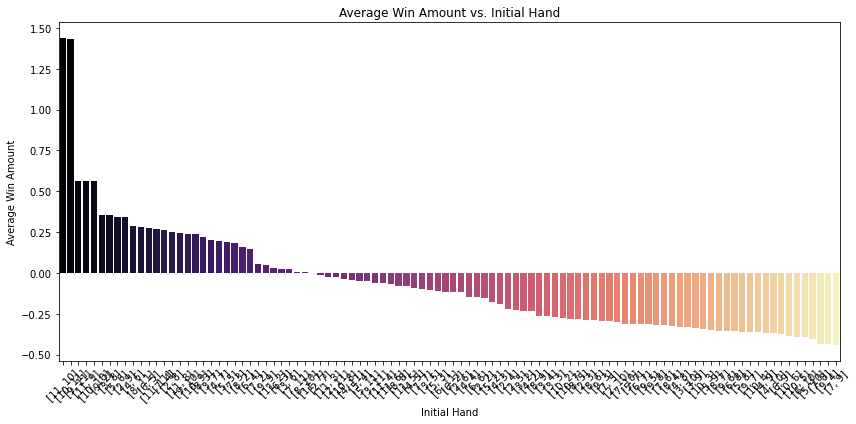

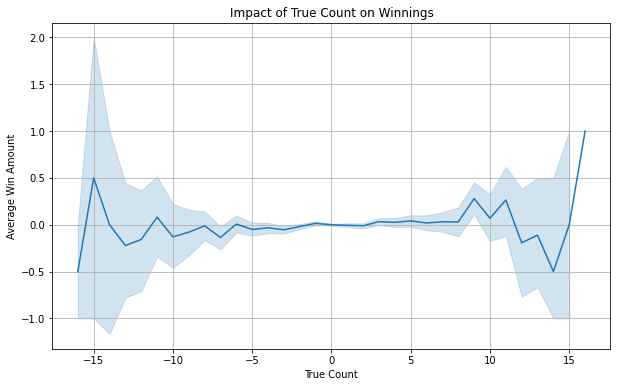

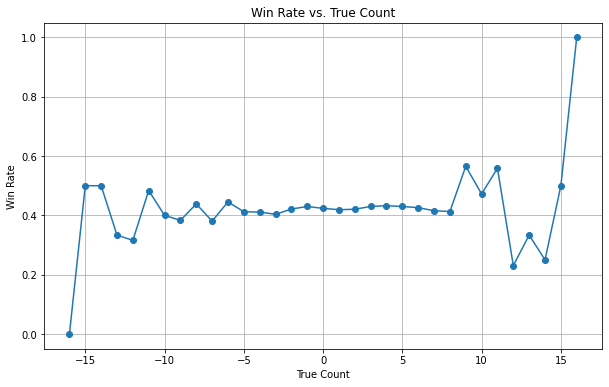

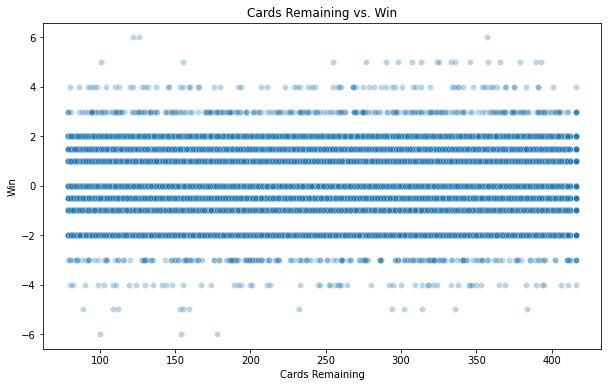

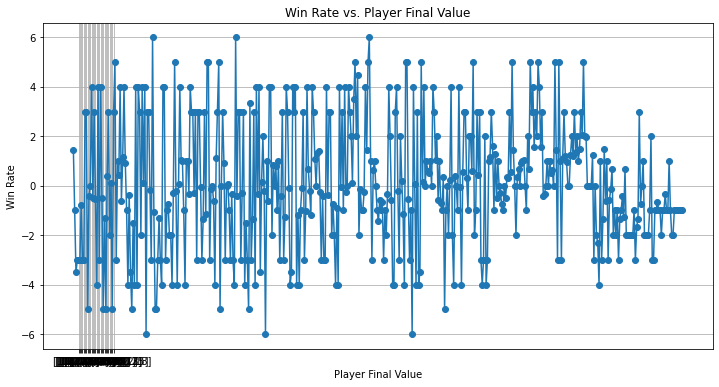

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (replace 'your_data.csv' with your actual filename)
try:
    df = pd.read_csv('blackjack_simulator.csv')
except FileNotFoundError:
    print("Error: blackjack.csv not found, please provide the right directory")
    exit()

df = df.sample(n=100000, random_state=42)  # Set random_state for reproducibility
df = df.reset_index(drop=True)

# 1. Overall Dataset Summary

print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDescriptive Statistics:\n", df.describe())
df.head()

# 2. Win/Loss Distribution

plt.figure(figsize=(8, 6))
sns.histplot(df['win'], kde=False)
plt.title('Distribution of Wins/Losses')
plt.xlabel('Win Amount')
plt.ylabel('Frequency')
plt.show()

win_percentage = (df['win'] > 0).mean() * 100
print(f"Win Percentage: {win_percentage:.2f}%")

# 3. Dealer Upcard Analysis: How does the dealer's upcard affect player outcomes?

dealer_up_wins = df.groupby('dealer_up')['win'].mean().sort_values(ascending=False)
print("\nAverage Win by Dealer Upcard:\n", dealer_up_wins)

plt.figure(figsize=(12, 6))
sns.barplot(x=dealer_up_wins.index, y=dealer_up_wins.values, palette='viridis')
plt.title('Average Win Amount vs. Dealer Upcard')
plt.xlabel('Dealer Upcard')
plt.ylabel('Average Win Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 4. Initial Hand Analysis:  Which starting hands are most profitable?

# Aggregate initial hand
initial_hand_wins = df.groupby('initial_hand')['win'].mean().sort_values(ascending=False)

print("\nAverage Win by Initial Hand:\n", initial_hand_wins)

plt.figure(figsize=(12, 6))
sns.barplot(x=initial_hand_wins.index, y=initial_hand_wins.values, palette='magma')
plt.title('Average Win Amount vs. Initial Hand')
plt.xlabel('Initial Hand')
plt.ylabel('Average Win Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. True Count Impact:  How does the true count influence winnings?

plt.figure(figsize=(10, 6))
sns.lineplot(x='true_count', y='win', data=df)
plt.title('Impact of True Count on Winnings')
plt.xlabel('True Count')
plt.ylabel('Average Win Amount')
plt.grid(True)
plt.show()

# True Count vs Win Rate
df['win_binary'] = df['win'].apply(lambda x: 1 if x > 0 else 0)
true_count_win_rate = df.groupby('true_count')['win_binary'].mean()

plt.figure(figsize=(10, 6))
plt.plot(true_count_win_rate.index, true_count_win_rate.values, marker='o')
plt.title('Win Rate vs. True Count')
plt.xlabel('True Count')
plt.ylabel('Win Rate')
plt.grid(True)
plt.show()

# 6. Cards Remaining vs. Win Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cards_remaining', y='win', data=df, alpha=0.3)
plt.title('Cards Remaining vs. Win')
plt.xlabel('Cards Remaining')
plt.ylabel('Win')
plt.show()

# 7. Player Final Value vs. Win Rate

player_final_win_rate = df.groupby('player_final_value')['win'].mean()

plt.figure(figsize=(12, 6))
plt.plot(player_final_win_rate.index, player_final_win_rate.values, marker='o')
plt.title('Win Rate vs. Player Final Value')
plt.xlabel('Player Final Value')
plt.ylabel('Win Rate')
plt.xticks(range(4, 32))
plt.grid(True)
plt.show()